#  Sleep Health & Cognitive Performance Analysis

##  Overview
This project analyzes a large-scale sleep health dataset containing 100,000 records. The goal is to understand how sleep patterns, lifestyle, and psychological factors influence sleep disorder risk and cognitive performance.

---



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


##  Dataset Information
- Total Records: 100,000  
- Total Features: 32  
- Missing Values: None  

The dataset includes:
- Demographics  
- Sleep architecture  
- Lifestyle habits  
- Psychological factors  
- Health context  
- Environmental factors  
- Target variables  

---


In [2]:
df = pd.read_csv('sleep_health_dataset.csv')

In [3]:
df.head(10)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0
5,6,23,Female,Driver,25.5,Brazil,8.16,5.7,17.3,20.1,...,71,1,0,22.7,0.70,Summer,Weekend,49.9,Mild,1
6,7,20,Female,Software Engineer,18.2,Netherlands,7.27,5.1,17.5,18.8,...,79,0,0,17.6,0.73,Spring,Weekend,57.9,Mild,1
7,8,48,Female,Freelancer,31.5,UK,8.04,6.5,25.3,22.3,...,60,1,0,21.6,0.47,Winter,Weekend,92.0,Mild,0
8,9,37,Male,Manager,29.9,USA,6.04,5.4,18.9,15.7,...,74,0,0,17.8,1.80,Autumn,Weekend,53.6,Mild,0
9,10,41,Female,Nurse,34.8,USA,6.22,4.9,21.4,15.5,...,80,1,0,24.4,1.51,Autumn,Weekday,67.8,Mild,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

##  Data Preprocessing
- Removed `person_id` as it is an identifier and not useful for modeling.
- Verified data types and ensured no missing values.

---

In [5]:
df.drop(columns=['person_id'], inplace=True)

##  Distribution Analysis

### Sleep Duration



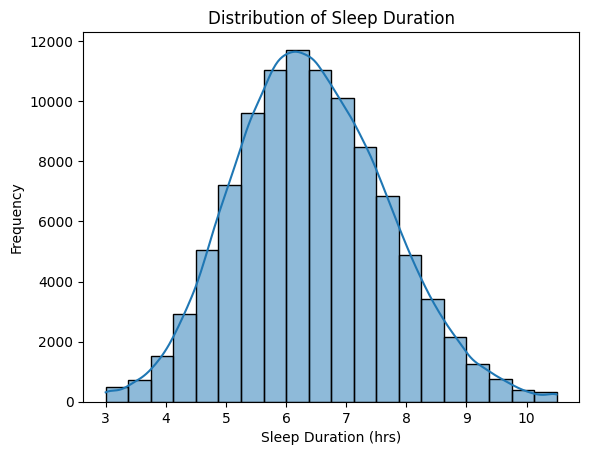

In [6]:
sns.histplot(df['sleep_duration_hrs'], bins=20, kde=True)
plt.title('Distribution of Sleep Duration')
plt.xlabel('Sleep Duration (hrs)')
plt.ylabel('Frequency')
plt.show()

Sleep duration follows an approximately normal distribution, centered around 6–7 hours, indicating most individuals get moderate sleep.

### Sleep Quality Score


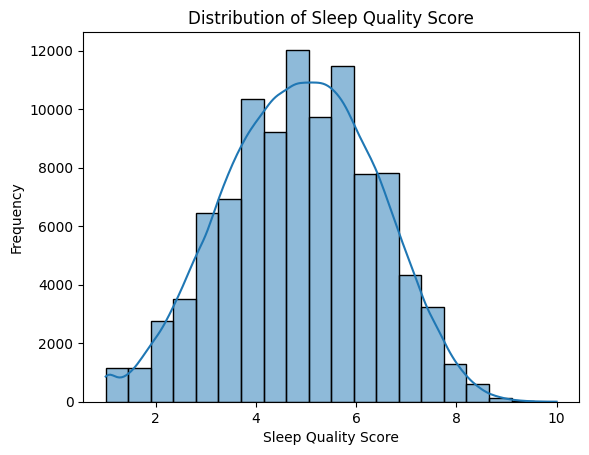

In [7]:
sns.histplot(df['sleep_quality_score'], bins=20, kde=True)
plt.title('Distribution of Sleep Quality Score')
plt.xlabel('Sleep Quality Score')
plt.ylabel('Frequency')
plt.show()


Sleep quality is also normally distributed, with most values between 4 and 7, suggesting moderate sleep quality across the population.

---

## Correlation Heatmap

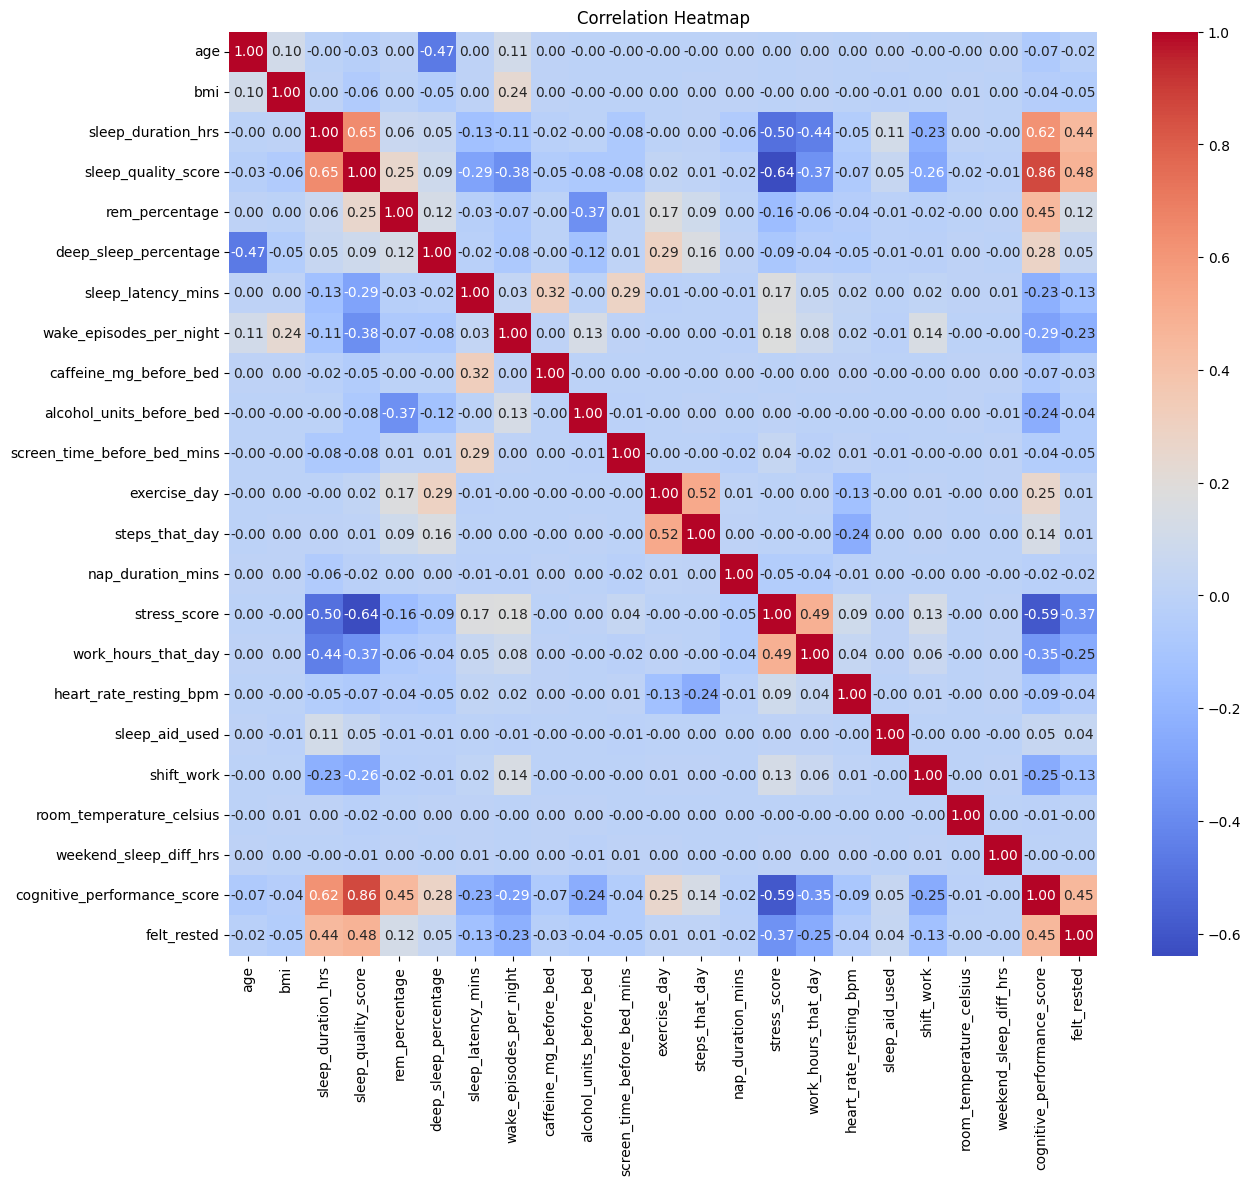

In [8]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


###  Key Findings

####  Strong Positive Correlations
- **sleep_quality_score → cognitive_performance_score (0.86)** 
- **sleep_duration_hrs → cognitive_performance_score (0.62)**  
- **rem_percentage → cognitive_performance_score (0.45)**  
- **felt_rested → cognitive_performance_score (0.45)**  *(target leakage)*  

> Higher sleep quality and adequate sleep duration significantly improve cognitive performance.

---

####  Strong Negative Correlations
- **stress_score → cognitive_performance_score (-0.59)** 
- **work_hours_that_day → cognitive_performance_score (-0.35)**  
- **wake_episodes_per_night → cognitive_performance_score (-0.29)**  
- **shift_work → cognitive_performance_score (-0.25)**  
- **alcohol_units_before_bed → cognitive_performance_score (-0.24)**  
- **sleep_latency_mins → cognitive_performance_score (-0.23)**  

> Increased stress, longer work hours, and disturbed sleep negatively impact cognitive performance.

---

####  Inter-feature Relationships
- **sleep_duration ↔ sleep_quality (0.65)**  
- **stress ↔ sleep_quality (-0.64)**  
- **stress ↔ work_hours (0.49)**  

> Work hours increase stress, which in turn reduces sleep quality and cognitive performance.

---

####  Weak Correlations
- Age, BMI, room temperature, and weekend sleep differences show minimal correlation with cognitive performance.

> These features have limited predictive power.

---

###  Important Note
- **felt_rested** should not be used as a feature when predicting cognitive performance, as it is a target variable and can cause data leakage.

---

###  Conclusion
The heatmap reveals that **sleep quality and stress are the most influential factors affecting cognitive performance**.

Sleep-related features (duration, REM) positively impact cognition, while psychological stress and lifestyle factors (work hours, alcohol) have a negative effect.

---

## Sleep Duration vs Sleep Disorder Risk

A boxplot was used to compare sleep duration across different levels of sleep disorder risk.


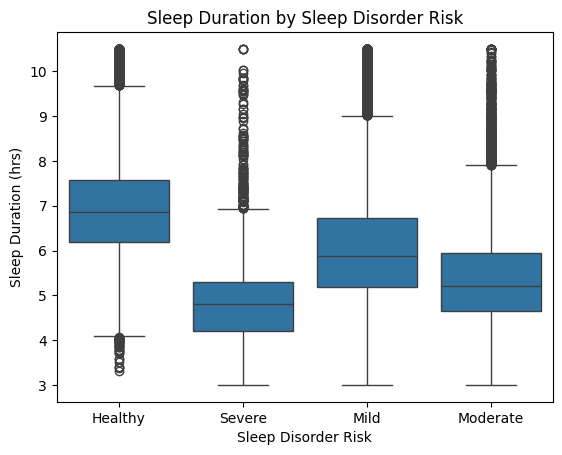

In [9]:
sns.boxplot(x='sleep_disorder_risk', y='sleep_duration_hrs', data=df)
plt.title('Sleep Duration by Sleep Disorder Risk')
plt.xlabel('Sleep Disorder Risk')
plt.ylabel('Sleep Duration (hrs)')
plt.show()

### Observations
- **Healthy individuals** have the highest median sleep duration (~6.5–7 hours)  
- **Severe cases** show the lowest sleep duration (~4–5 hours)  
- **Mild and Moderate cases** fall in between  

There is a clear decreasing trend in sleep duration as disorder severity increases.

---

### Insight
This indicates a strong relationship between **reduced sleep duration and higher sleep disorder risk**.

Individuals with severe sleep disorders tend to sleep significantly less than healthy individuals.

---

### Conclusion
Sleep duration is a **key predictor of sleep disorder risk**, with shorter sleep strongly associated with higher severity levels.

---

##  Stress Score vs Work Hours

A regression plot was used to examine the relationship between stress levels and daily work hours.


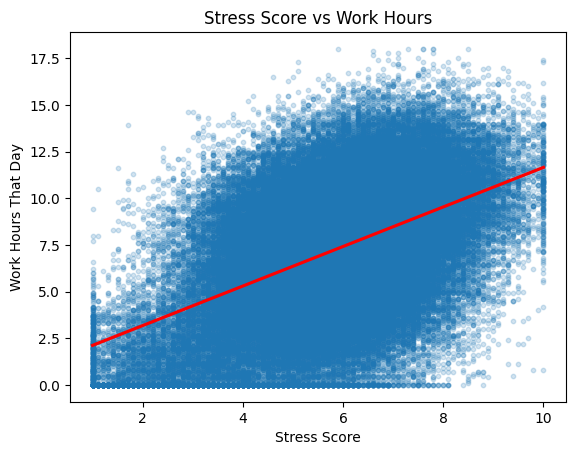

In [10]:
sns.regplot(
    x='stress_score', 
    y='work_hours_that_day', 
    data=df, 
    scatter_kws={'alpha':0.2, 's':10},
    line_kws={'color':'red'},
    ci=95
)
plt.title('Stress Score vs Work Hours')
plt.xlabel('Stress Score')
plt.ylabel('Work Hours That Day')
plt.show()


###  Observations
- A clear **positive linear trend** is observed  
- As **work hours increase**, the **stress score also increases**  
- Despite some variability, the overall trend is strong and consistent  

---

###  Insight
This indicates that **longer working hours contribute significantly to higher stress levels**.

Workload appears to be a major psychological factor affecting individuals.

---

###  Relationship Chain
Work Hours → Stress ↑ → Sleep Quality ↓ → Cognitive Performance ↓  

---

###  Conclusion
Work hours are an important indirect factor influencing sleep and cognitive outcomes through increased stress levels.

---

##  Stress Score vs Cognitive Performance

A regression plot was used to analyze the relationship between stress levels and cognitive performance.


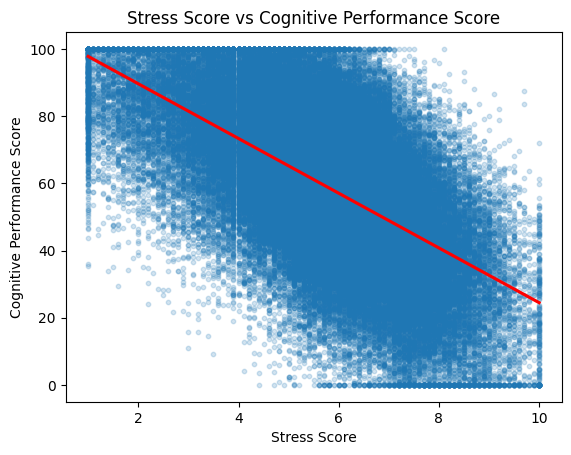

In [11]:
sns.regplot(
    x='stress_score', 
    y='cognitive_performance_score', 
    data=df, 
    scatter_kws={'alpha':0.2, 's':10},
    line_kws={'color':'red'},
    ci=95
)
plt.title('Stress Score vs Cognitive Performance Score')
plt.xlabel('Stress Score')
plt.ylabel('Cognitive Performance Score')
plt.show()



###  Observations
- A strong **negative linear relationship** is clearly visible  
- As **stress score increases**, **cognitive performance decreases significantly**  
- The trend line shows a steep downward slope, indicating a strong effect  

---

###  Insight
This suggests that **stress is one of the most critical factors affecting cognitive performance**.

High stress levels lead to reduced focus, memory, and overall mental efficiency.

---

###  Key Finding
Stress has a **stronger impact on cognitive performance than most other variables in the dataset**.

---

###  Conclusion
Managing stress is essential for maintaining high cognitive performance. Reducing stress levels can significantly improve mental outcomes and productivity.

---

##  Stress Score by Felt Rested

A boxplot was used to compare stress levels between individuals who felt rested and those who did not.


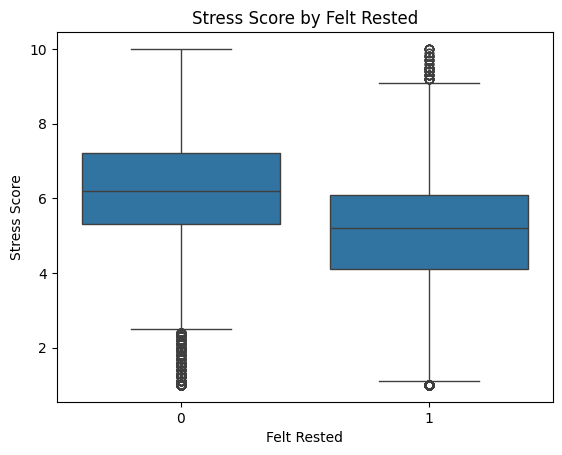

In [12]:
sns.boxplot(x='felt_rested', y='stress_score', data=df)
plt.title('Stress Score by Felt Rested')
plt.xlabel('Felt Rested')
plt.ylabel('Stress Score')
plt.show()


### Observations
- Individuals who **did not feel rested (0)** have **higher stress levels**  
- Individuals who **felt rested (1)** show **lower median stress scores**  
- The distribution for non-rested individuals is shifted toward higher stress values  

---

### Insight
This indicates a strong relationship between **restfulness and stress levels**.

People who feel rested tend to experience lower stress, while lack of rest is associated with higher stress.

---

### Relationship
Poor Sleep → Not Rested → Higher Stress  

---

### Conclusion
Perceived restfulness is closely linked to psychological well-being, with lower stress levels observed in individuals who feel adequately rested.

---

##  Sleep Aid Effect: Healthy vs Severe Cases

A grouped boxplot was used to compare sleep quality scores across sleep disorder risk levels, with and without sleep aid usage.


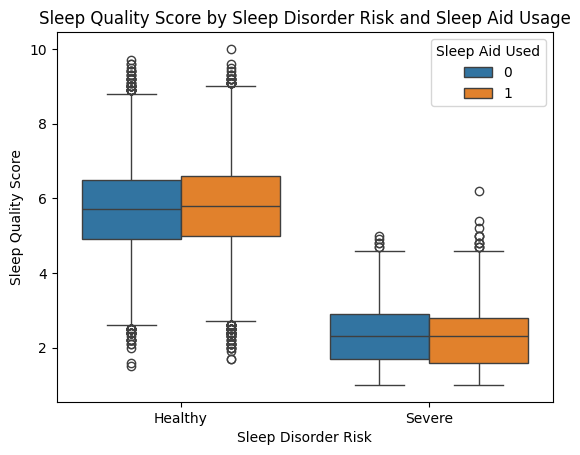

In [13]:
df_filtered = df[df['sleep_disorder_risk'].isin(['Healthy', 'Severe'])]

sns.boxplot(
    x='sleep_disorder_risk',
    y='sleep_quality_score',
    hue='sleep_aid_used',
    data=df_filtered
)
plt.title('Sleep Quality Score by Sleep Disorder Risk and Sleep Aid Usage')
plt.xlabel('Sleep Disorder Risk')
plt.ylabel('Sleep Quality Score')
plt.legend(title='Sleep Aid Used')
plt.show()


### Observations

#### Healthy Individuals
- Sleep quality is relatively high in both cases  
- Slight improvement is observed with sleep aid usage  

#### Severe Cases
- Sleep quality is significantly lower compared to healthy individuals  
- Sleep aids provide **minor improvement**, but the overall quality remains low  

---

### Insight
Sleep aids help improve sleep quality, but their effect is **limited**, especially for individuals with severe sleep disorders.

Even with sleep aids, severe cases do not reach the sleep quality levels of healthy individuals.

---

### Key Finding
Sleep aids provide **partial relief**, not a complete solution.

---

### Conclusion
While sleep aids can enhance sleep quality, they do not fully restore normal sleep in individuals with severe sleep disorders. Addressing underlying causes such as stress and lifestyle factors is essential.

---

##  Caffeine Intake Before Bed vs Sleep Quality

A line plot was used to analyze the relationship between caffeine consumption before bedtime and sleep quality.


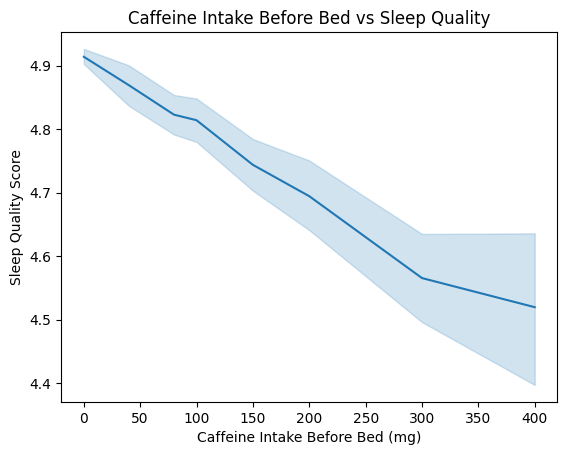

In [14]:
sns.lineplot(x='caffeine_mg_before_bed', y='sleep_quality_score', data=df)
plt.title('Caffeine Intake Before Bed vs Sleep Quality')
plt.xlabel('Caffeine Intake Before Bed (mg)')
plt.ylabel('Sleep Quality Score')
plt.show()



###  Observations
- A clear **negative trend** is observed  
- As **caffeine intake increases**, **sleep quality decreases**  
- The decline is gradual but consistent across the range  

---

###  Insight
This indicates that **higher caffeine consumption before bed negatively impacts sleep quality**.

Even moderate amounts of caffeine show a noticeable reduction in sleep quality.

---

###  Key Finding
Caffeine intake has a **direct and measurable negative effect on sleep quality**.

---

###  Conclusion
Reducing caffeine consumption before bedtime can significantly improve sleep quality and overall sleep health.

---

##  Alcohol Intake Before Bed vs Sleep Quality

A line plot was used to analyze the relationship between alcohol consumption before bedtime and sleep quality.


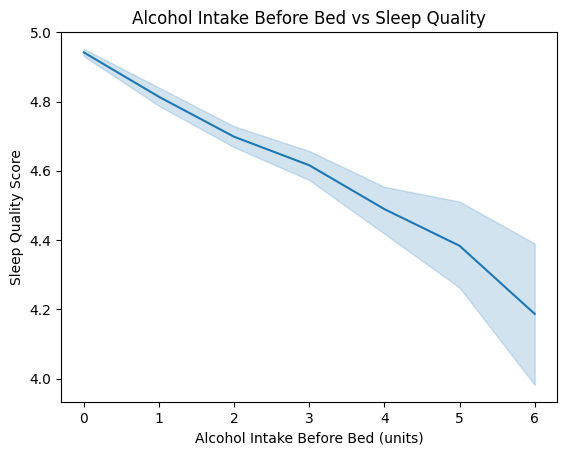

In [15]:
sns.lineplot(x='alcohol_units_before_bed', y='sleep_quality_score', data=df)
plt.title('Alcohol Intake Before Bed vs Sleep Quality')
plt.xlabel('Alcohol Intake Before Bed (units)')
plt.ylabel('Sleep Quality Score')
plt.show()



###  Observations
- A clear **negative trend** is observed  
- As **alcohol intake increases**, **sleep quality decreases significantly**  
- The decline becomes steeper at higher alcohol levels  

---

###  Insight
This suggests that **alcohol consumption before bed has a strong negative impact on sleep quality**.

Higher alcohol intake leads to poorer sleep, likely due to disrupted sleep cycles.

---

###  Key Finding
Alcohol has a **stronger negative effect on sleep quality compared to many other lifestyle factors**.

---

###  Conclusion
Limiting alcohol consumption before bedtime is important for maintaining good sleep quality and overall sleep health.

---

##  Age vs Sleep Quality

A regression plot was used to analyze the relationship between age and sleep quality.


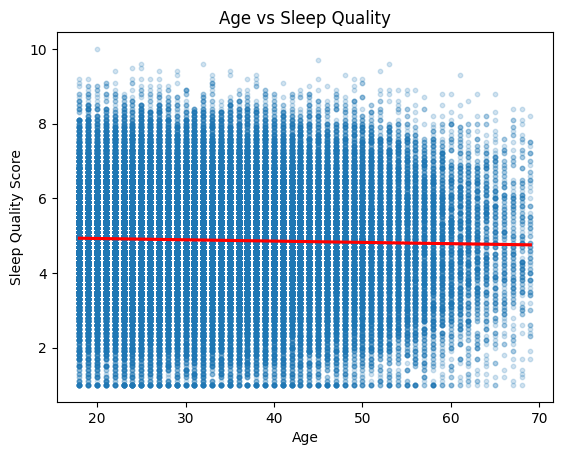

In [16]:
sns.regplot(
    x='age',
    y='sleep_quality_score',
    data=df,
    scatter_kws={'alpha':0.2, 's':10},
    line_kws={'color':'red'}
)

plt.title('Age vs Sleep Quality')
plt.xlabel('Age')
plt.ylabel('Sleep Quality Score')
plt.show()




###  Observations
- The regression line is **almost flat**, indicating no strong trend  
- A very slight **negative relationship** is observed  
- Data points are widely spread across all age groups  

---

###  Insight
This suggests that **age has a minimal impact on sleep quality**.

Sleep quality does not significantly change with age compared to other influencing factors.

---

###  Key Finding
Age is a **weak predictor** of sleep quality in this dataset.

---

###  Conclusion
Factors such as **stress, sleep duration, and lifestyle habits** play a much more significant role in determining sleep quality than age.

---

##  Key Findings Summary

- **Sleep quality is the strongest predictor of cognitive performance**, followed by sleep duration and REM sleep.

- **Stress has the most significant negative impact** on cognitive performance and sleep quality.

- **Work hours increase stress**, indirectly reducing sleep quality and cognitive performance.

- **Sleep duration is strongly linked to sleep disorder risk**, with shorter sleep associated with higher severity.

- **Sleep aids provide only partial improvement**, especially in severe cases, and do not restore normal sleep quality.

- **Caffeine and alcohol consumption before bed negatively affect sleep quality**, with alcohol showing a stronger impact.

- **Exercise has a positive but moderate effect** on sleep quality.

- **Age has minimal influence on sleep quality**, making it a weak predictor.

- **Perceived restfulness is associated with lower stress levels**, indicating a strong connection between sleep and mental well-being.

---

##  Final Conclusion

Sleep health is primarily driven by **sleep quality and stress levels**, with lifestyle habits acting as key supporting factors. Managing stress and improving sleep habits can significantly enhance cognitive performance and overall well-being.

Now that we see how stress impacts the brain, let's look at what lifestyle choices drive that stress.

---

## Model Evaluation and Comparison

Multiple machine learning models were implemented and evaluated to predict sleep disorder risk. The models were compared using Accuracy, Macro F1-score, and Weighted F1-score.

---

## RandomForest Classifier

Random Forest was used as a baseline ensemble model due to its ability to handle non-linear relationships and mixed feature types.


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


In [18]:
X = df.drop(columns=[
    'sleep_disorder_risk',
    'cognitive_performance_score',
    'felt_rested',
    'age', 'bmi',
    'room_temperature_celsius', 
    'weekend_sleep_diff_hrs'
])
y = df['sleep_disorder_risk']



In [19]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


In [20]:
Rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    class_weight='balanced'
)
Rf.fit(X_train, y_train)
y_pred = Rf.predict(X_test)

In [21]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

     Healthy       0.92      0.88      0.90     10892
        Mild       0.74      0.73      0.74      6673
    Moderate       0.45      0.59      0.51      1626
      Severe       0.62      0.72      0.67       809

    accuracy                           0.80     20000
   macro avg       0.68      0.73      0.70     20000
weighted avg       0.81      0.80      0.80     20000



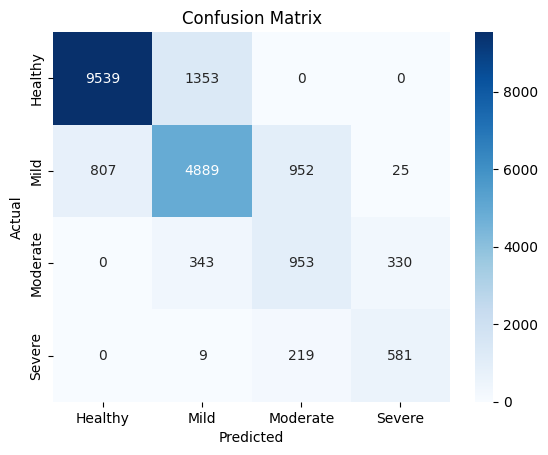

In [22]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

- Accuracy: 79.81%  
- Macro F1-score: 0.70  
- Weighted F1-score: 0.80  

**Insight:**  
Random Forest performed well overall and handled most classes effectively. However, its performance on minority classes was slightly lower compared to advanced boosting methods.

---


In [35]:
from sklearn.metrics import accuracy_score, f1_score

results = []

def evaluate_model(name, y_test, y_pred):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average='macro'),
        "Weighted F1": f1_score(y_test, y_pred, average='weighted')
    })
evaluate_model("Random Forest", y_test, y_pred)

## XGBoost Classifier

XGBoost was implemented as an advanced ensemble model known for high performance and efficiency.


In [24]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X = pd.get_dummies(X, drop_first=True)
X.columns = X.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [25]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


C:\Users\akshg\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:31:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [26]:
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

              precision    recall  f1-score   support

     Healthy       0.91      0.94      0.93     10892
        Mild       0.80      0.80      0.80      6673
    Moderate       0.57      0.48      0.52      1626
      Severe       0.73      0.63      0.68       809

    accuracy                           0.84     20000
   macro avg       0.75      0.71      0.73     20000
weighted avg       0.84      0.84      0.84     20000



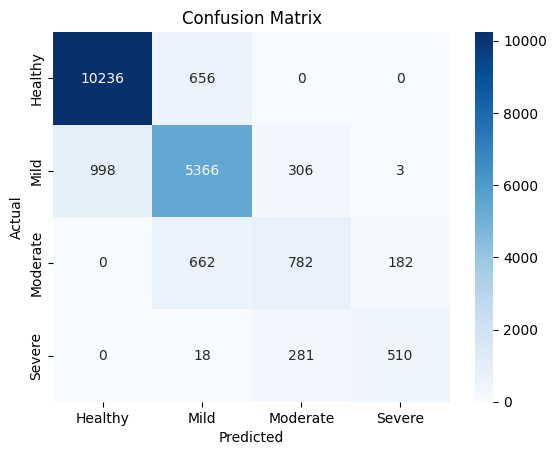

In [27]:
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

- Accuracy: 84.47%  
- Macro F1-score: 0.73  
- Weighted F1-score: 0.84  

**Insight:**  
XGBoost achieved the best performance among all models. It handled class imbalance effectively and provided the highest accuracy and balanced F1-scores across all classes.

---

In [36]:
evaluate_model("XGBoost", y_test, y_pred_xgb)

## Linear SVM
Linear Support Vector Machine was used as a fast alternative to kernel-based SVM for large datasets.

In [29]:
from sklearn.svm import LinearSVC

svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [30]:
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

              precision    recall  f1-score   support

     Healthy       0.84      0.95      0.89     10892
        Mild       0.62      0.70      0.66      6673
    Moderate       0.00      0.00      0.00      1626
      Severe       0.90      0.19      0.31       809

    accuracy                           0.76     20000
   macro avg       0.59      0.46      0.46     20000
weighted avg       0.70      0.76      0.72     20000



C:\Users\akshg\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\akshg\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\akshg\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

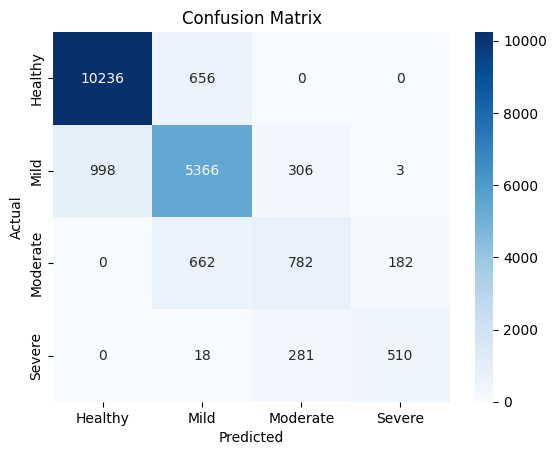

In [31]:
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

- Accuracy: 75.63%  
- Macro F1-score: 0.46  
- Weighted F1-score: 0.71  

**Insight:**  
Linear SVM showed significantly lower performance, especially on minority classes. It struggled to capture complex non-linear relationships present in the dataset.

---

In [37]:
evaluate_model("Linear SVM", y_test, y_pred_svm)

In [38]:
df_results = pd.DataFrame(results)


In [39]:
df_results

,Model,Accuracy,Macro F1,Weighted F1
0,Random Forest,0.79810,0.702370,0.803375
1,XGBoost,0.84470,0.732009,0.841495
2,Linear SVM,0.75635,0.464486,0.715898


##  Model Comparison

Multiple models were evaluated including Random Forest, XGBoost, and Linear SVM.

- XGBoost achieved the best performance with an accuracy of 84.47% and Macro F1-score of 0.73.
- Random Forest performed well but was slightly less accurate.
- Linear SVM showed significantly lower performance, particularly on minority classes.

###  Conclusion
XGBoost was selected as the final model due to its superior performance and ability to handle class imbalance effectively.

##  Final Conclusion

This project analyzed sleep health data to understand the impact of sleep patterns, lifestyle habits, and psychological factors on sleep disorder risk and cognitive performance.

The analysis revealed that **sleep quality, sleep duration, and stress levels are the most influential factors**. High stress and longer work hours negatively impact sleep and cognitive performance, while good sleep quality significantly improves mental outcomes.

Lifestyle habits such as **caffeine and alcohol consumption before bed were found to reduce sleep quality**, whereas exercise showed a positive effect. Additionally, sleep aids provided only partial improvement, especially in severe cases, indicating that underlying causes must be addressed.

From a modeling perspective, multiple machine learning algorithms were evaluated. **XGBoost emerged as the best-performing model**, achieving the highest accuracy and balanced performance across all classes. This highlights the importance of using advanced ensemble techniques for complex, real-world datasets.

---

##  Closing Statement

This project demonstrates how data-driven insights can be used to better understand sleep health and its broader impact on human performance. By identifying key factors such as stress and sleep quality, this analysis provides actionable insights that can help improve well-being and productivity.

Overall, the combination of exploratory data analysis, feature engineering, and machine learning modeling resulted in a robust and practical solution for predicting sleep disorder risk.